In [ ]:
!pip install tensorflow.keras opencv-python

In [35]:
import matplotlib.pyplot as plt
import cv2
import tensorflow.keras

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/artifact-dataset")

print("Path to dataset files:", path)

100%|██████████| 29.4G/29.4G [05:29<00:00, 95.9MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1


In [36]:
import tensorflow as tf

#data handeling first

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [37]:
import os
import pandas as pd

data_dir = '/root/.cache/kagglehub/datasets/awsaf49/artifact-dataset'  # Directory containing the data

metadata_list = []

# Iterate through all folders and subfolders in the data directory
for folder, subfolders, files in os.walk(data_dir):
    for file in files:
        # Check if the file is named "metadata.csv"
        if file == 'metadata.csv':
            metadata_file = os.path.join(folder, file)
            print("Loading metadata from:", metadata_file)
            # Read the metadata file into a pandas DataFrame
            metadata = pd.read_csv(metadata_file)
            # Add a column with the directory path of the metadata file
            metadata['file_path'] = os.path.dirname(metadata_file)
            # Append the DataFrame to the list
            metadata_list.append(metadata)

# Check if any metadata files were found
if len(metadata_list) == 0:
    print("No metadata found.")
else:
    # Concatenate all DataFrames in the list into a single DataFrame
    metadata_df = pd.concat(metadata_list)
    print("Total number of entries in metadata_df:", len(metadata_df))

Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/stable_diffusion/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/face_synthetics/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/star_gan/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/celebahq/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/metfaces/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/cips/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/cycle_gan/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/big_gan/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versi

In [38]:
print(metadata_df)

             filename                        image_path  target category  \
0       img000000.jpg  stable-face/Female/img000000.jpg       6   Female   
1       img000001.jpg  stable-face/Female/img000001.jpg       6   Female   
2       img000002.jpg  stable-face/Female/img000002.jpg       6   Female   
3       img000003.jpg  stable-face/Female/img000003.jpg       6   Female   
4       img000004.jpg  stable-face/Female/img000004.jpg       6   Female   
...               ...                               ...     ...      ...   
539158  img014995.jpg         horse/horse/img014995.jpg       0    horse   
539159  img115687.jpg         horse/horse/img115687.jpg       0    horse   
539160  img115912.jpg         horse/horse/img115912.jpg       0    horse   
539161  img116673.jpg         horse/horse/img116673.jpg       0    horse   
539162  img013218.jpg         horse/horse/img013218.jpg       0    horse   

                                                file_path  
0       /root/.cache/kaggle

In [39]:
metadata_df["full_path"]=metadata_df.apply(lambda row: os.path.join(row["file_path"], row["image_path"]), axis=1)
print(metadata_df.head())

        filename                        image_path  target category  \
0  img000000.jpg  stable-face/Female/img000000.jpg       6   Female   
1  img000001.jpg  stable-face/Female/img000001.jpg       6   Female   
2  img000002.jpg  stable-face/Female/img000002.jpg       6   Female   
3  img000003.jpg  stable-face/Female/img000003.jpg       6   Female   
4  img000004.jpg  stable-face/Female/img000004.jpg       6   Female   

                                           file_path  \
0  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
1  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
2  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
3  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
4  /root/.cache/kagglehub/datasets/awsaf49/artifa...   

                                           full_path  
0  /root/.cache/kagglehub/datasets/awsaf49/artifa...  
1  /root/.cache/kagglehub/datasets/awsaf49/artifa...  
2  /root/.cache/kagglehub/datasets/awsaf49/artifa...  
3  /root/.cache/

In [40]:
metadata_df.isna().sum()

,0
filename,0
image_path,0
target,0
category,170654
file_path,0
full_path,0


In [41]:
metadata_df = metadata_df.fillna("Not Available")

In [42]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2496738 entries, 0 to 539162
Data columns (total 6 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   filename    object
 1   image_path  object
 2   target      int64 
 3   category    object
 4   file_path   object
 5   full_path   object
dtypes: int64(1), object(5)
memory usage: 133.3+ MB


In [43]:
metadata_df["target"].value_counts()

,count
target,
1,1000000
0,964989
6,286352
5,105000
2,97494
4,22000
3,20903


In [44]:
metadata_df["target"] = metadata_df["target"].apply(lambda row : 1 if row in {6,5,2,3,4,1} else 0 )

In [45]:
metadata_df["target"].value_counts()

,count
target,
1,1531749
0,964989


In [46]:
metadata_df = metadata_df.reset_index(drop=True)

In [47]:
metadata_df["full_path"][0]

'/root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/stable_diffusion/stable-face/Female/img000000.jpg'

In [48]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(metadata_df, test_size=0.2,random_state=42 ,stratify=metadata_df["target"])

In [49]:
train_df["target"].value_counts(normalize=True)

,proportion
target,
1,0.6135
0,0.3865


In [50]:
test_df["target"].value_counts(normalize=True)

,proportion
target,
1,0.6135
0,0.3865


In [51]:
img=cv2.imread(train_df["full_path"][1])

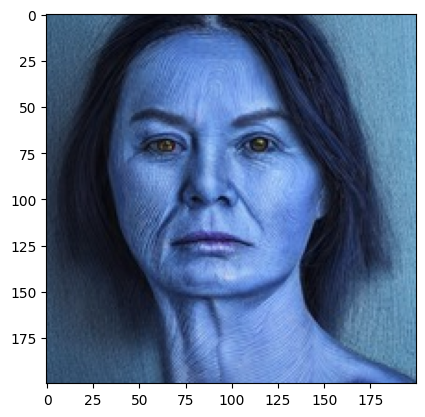

In [52]:
plt.imshow(img)

In [53]:
from sklearn.model_selection import train_test_split

# Assuming 'label' is the column name containing your image classes
# This takes 20% of your train data and turns it into validation data
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df['target'],
)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

Train size: 1597912 | Val size: 399478 | Test size: 499348


In [54]:
# %% ---- Cell A: fast input pipeline (replaces cells 20 + 21) -----------------
import os
import numpy as np
import tensorflow as tf

IMG = 200
BATCH = 128                      # T4 has room; 64 -> 128 keeps the GPU busier
AUTOTUNE = tf.data.AUTOTUNE

# Labels stay integers now (the old astype(str) is what broke class_weight).
for d in (train_df, val_df, test_df):
    d["target"] = d["target"].astype(int)

# Validation on 400k images every epoch is very expensive -> use a fixed sample.
val_small = val_df.sample(50_000, random_state=42)


def make_ds(df, training, cache_path=None):
    """paths -> parallel decode (straight to grayscale) -> crop -> batch -> prefetch"""
    paths = df["full_path"].values
    labels = df["target"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training and cache_path is None:
        ds = ds.shuffle(50_000)          # cheap: shuffles path strings only

    def load(path, y):
        raw = tf.io.read_file(path)
        # channels=1: decoder outputs grayscale directly (your FFT layer threw
        # colour away anyway) -> 3x less data, no rgb_to_grayscale on the GPU.
        img = tf.io.decode_image(raw, channels=1, expand_animations=False)
        img.set_shape([None, None, 1])
        # Center-crop instead of resize: resizing/rotating smooths the exact
        # high-frequency traces the FFT is supposed to detect.
        # (If you prefer resizing, swap for tf.image.resize(img, (IMG, IMG)).)
        img = tf.image.resize_with_crop_or_pad(img, IMG, IMG)
        return img, y                     # uint8, scaled to [0,1] inside the model

    ds = ds.map(load, num_parallel_calls=AUTOTUNE, deterministic=not training)
    ds = ds.ignore_errors()               # skip any corrupt file instead of crashing hours in

    if cache_path is not None:
        # Optional: decode once, replay from local disk next epochs.
        # Use with a SUBSET (~40 KB per image -> 300k images ~ 12 GB).
        ds = ds.cache(cache_path)
        if training:
            ds = ds.shuffle(20_000)       # shuffle AFTER cache so order changes every epoch

    if training:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)


train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_small, training=False)
test_ds  = make_ds(test_df,  training=False)

In [55]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)

# Mixed precision = fp16 tensor cores on the T4 (big speed-up for the convs).
tf.keras.mixed_precision.set_global_policy("mixed_float16")


class FFTLayer(tf.keras.layers.Layer):
    def call(self, x):
        x = tf.cast(x, tf.float32) / 255.0          # uint8 -> [0,1]  (replaces rescale=1/255)
        x = tf.squeeze(x, axis=-1)                  # already grayscale
        f = tf.signal.fft2d(tf.cast(x, tf.complex64))
        f = tf.signal.fftshift(f, axes=(-2, -1))
        m = tf.math.log1p(tf.abs(f))
        return tf.expand_dims(m, -1)

In [60]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
# FFT layer



model = Sequential([

    tf.keras.Input(shape=(IMG, IMG, 1), dtype="uint8"),
    FFTLayer(dtype="float32"),                      # keep the FFT itself in fp32
    BatchNormalization(),                           # log-spectrum is un-normalised; this helps a lot

    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),


    Flatten(),

    # Fully connected layers
    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy",        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fft_layer_2 (FFTLayer)          │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 200, 1)    │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,858,309 (37.61 MB)

 Trainable params: 9,858,307 (37.61 MB)

 Non-trainable params: 2 (8.00 B)

In [61]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(   # Colab can disconnect -> always save
    "best_model.keras", monitor="val_loss", save_best_only=True, verbose=1)

import datetime

version = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

log_dir = f"logs/model/{version}"

tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=0
)

In [62]:
y_train=train_df["target"]

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {1: weights[1], 0: weights[0]}

print(class_weights)

{1: np.float64(0.8149959349966694), 0: np.float64(1.2936610356658835)}


In [63]:
history = model.fit(
    train_ds.repeat(),
    steps_per_epoch=4000,
    validation_data=val_ds,
    validation_steps=390,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint, tensorboard],
)

Epoch 1/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6157 - auc: 0.6681 - loss: 0.6474 - precision: 0.7290 - recall: 0.5963
Epoch 1: val_loss improved from None to 0.62117, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 642s 158ms/step - accuracy: 0.6356 - auc: 0.6957 - loss: 0.6317 - precision: 0.7475 - recall: 0.6135 - val_accuracy: 0.6519 - val_auc: 0.7308 - val_loss: 0.6212 - val_precision: 0.7831 - val_recall: 0.6010
Epoch 2/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6593 - auc: 0.7322 - loss: 0.6049 - precision: 0.7729 - recall: 0.6293
Epoch 2: val_loss improved from 0.62117 to 0.57730, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 631s 158ms/step - accuracy: 0.6632 - auc: 0.7388 - loss: 0.5989 - precision: 0.7786 - recall: 0.6300 - val_accuracy: 0.6806 - val_auc: 0.7604 - val_loss: 0.5773 - val_precision: 0

In [64]:
model.evaluate(test_ds)

3902/3902 ━━━━━━━━━━━━━━━━━━━━ 572s 147ms/step - accuracy: 0.7182 - auc: 0.8090 - loss: 0.5233 - precision: 0.8215 - recall: 0.6908


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.5232892036437988,
 0.7182486057281494,
 0.8215436339378357,
 0.690804660320282,
 0.8089749217033386]

In [65]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/content/drive/MyDrive/artifact_detector', exist_ok=True)
shutil.copy('/content/best_model.keras', '/content/drive/MyDrive/artifact_detector/best_model_fft_baseline.keras')

Mounted at /content/drive


'/content/drive/MyDrive/artifact_detector/best_model_fft_baseline.keras'